In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from simulate_missingness import (
    selection_mar_logistic,
    selection_mnar_on_y,
    test_mnar_vs_mar,
    compare_distributions
)

In [2]:
rng = np.random.default_rng(42)
n = 2000
k = 4
X = rng.normal(size=(n, k))
# give columns friendly names
col_names = [f"X{i}" for i in range(k)]
df = pd.DataFrame(X, columns=col_names)
# Build a label 'BAD' correlated with features (rough signal)
coefs = np.array([0.8, -1.2, 0.4, 0.2])
logit = df.values @ coefs
p_bad = 1 / (1 + np.exp(- (logit - 0.2)))
df['BAD'] = (rng.random(n) < p_bad).astype(int)

In [3]:
mask_mar, probs_mar = selection_mar_logistic(df, col_names, rng, intercept=-0.5, stochastic=True)
print("MAR diagnostic:")
test_mnar_vs_mar(df, mask_mar, col_names)

# 3) Run MNAR selection (depends on true label Y)
mask_mnar, probs_mnar = selection_mnar_on_y(df, col_names, rng, beta_y=1.8, intercept=-1.0, stochastic=True)
print("MNAR diagnostic:")
test_mnar_vs_mar(df, mask_mnar, col_names)

MAR diagnostic:
[diagnostic] logistic R ~ X + Y: coef on Y = -0.0168  --> MAR-like (small)
[diagnostic] P(R=1 | Y=1) = 0.460, P(R=1 | Y=0) = 0.529
MNAR diagnostic:
[diagnostic] logistic R ~ X + Y: coef on Y = 0.9725  --> MNAR-like
[diagnostic] P(R=1 | Y=1) = 0.768, P(R=1 | Y=0) = 0.261


{'coef_y': 0.972512865765444}


Mean differences (MAR): {'X0': -0.08387680714541867, 'X1': 0.2455561370815733, 'X2': 0.40008452798071686, 'X3': -0.04759580884807358}
Mean differences (MNAR): {'X0': 0.053668018956050695, 'X1': -0.4577721000622626, 'X2': 0.0232237578314855, 'X3': 0.06596668392852857}


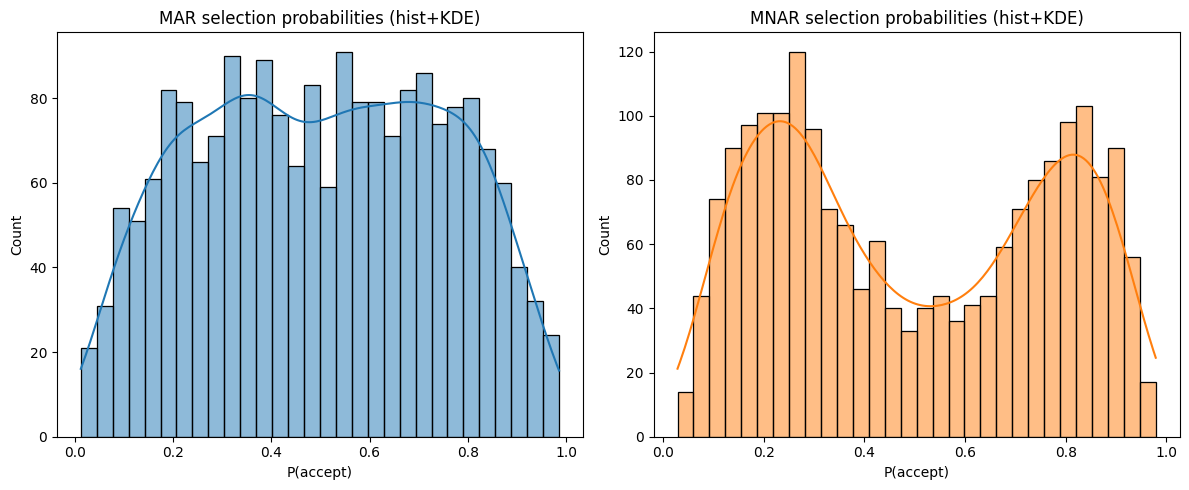

In [4]:
# 4) Quick distribution compare (accepted vs population)
diffs_mar = compare_distributions(df, mask_mar, col_names)
diffs_mnar = compare_distributions(df, mask_mnar, col_names)
print("\nMean differences (MAR):", {c: diffs_mar[c]['acc_mean'] - diffs_mar[c]['pop_mean'] for c in col_names})
print("Mean differences (MNAR):", {c: diffs_mnar[c]['acc_mean'] - diffs_mnar[c]['pop_mean'] for c in col_names})

# 5) Plot selection probabilities and KDEs for illustration
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
sns.histplot(probs_mar, bins=30, kde=True, color='C0')
plt.title('MAR selection probabilities (hist+KDE)')
plt.xlabel('P(accept)')

plt.subplot(1,2,2)
sns.histplot(probs_mnar, bins=30, kde=True, color='C1')
plt.title('MNAR selection probabilities (hist+KDE)')
plt.xlabel('P(accept)')
plt.tight_layout()
plt.show()

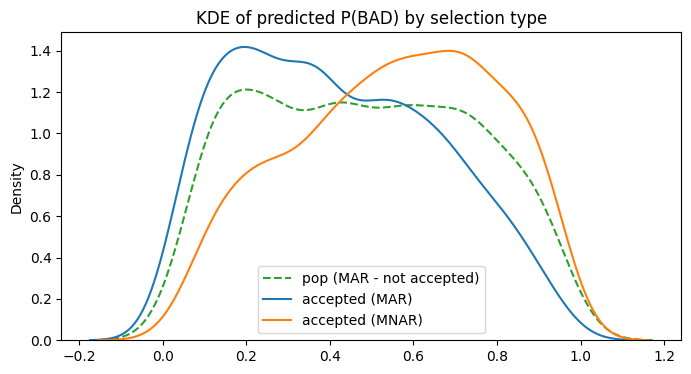

In [5]:
# 6) KDE of model-implied P(BAD) for accepted vs population (use simple logistic model using X)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[col_names].values)
clf = LogisticRegression().fit(X_scaled, df['BAD'].values)
probs_all = clf.predict_proba(X_scaled)[:, 1]

plt.figure(figsize=(8,4))
sns.kdeplot(probs_all[df.index[~mask_mar]], label='pop (MAR - not accepted)', color='C2', linestyle='--')
sns.kdeplot(probs_all[df.index[mask_mar]], label='accepted (MAR)', color='C0')
sns.kdeplot(probs_all[df.index[mask_mnar]], label='accepted (MNAR)', color='C1')
plt.title('KDE of predicted P(BAD) by selection type')
plt.legend()
plt.show()

In [ ]:
# ---- How to adapt to your DataGenerator (quick)
# If you already use your repo's DataGenerator (imported as `data` and instance `res`):
# 1) create res and generate the full population:
#    res = data.DataGenerator(...); df = res.generate()   # if res.generate returns a DataFrame
#    # or if res stores data on res.some_attribute, inspect res to find the DataFrame
# 2) set X_cols = list_of_continuous_columns_in_df
# 3) call selection_mnar_on_y(df, X_cols, rng, ...) or selection_mar_logistic(...)
# 4) proceed with diagnostics and replace plotting code above with your plots